# Лабораторная работа 2. Анализ изображения: гистограммы, профили и проекции

**Вариант 9**

Цель работы: исследовать распределение яркости изображения, построить профили после фильтра Лапласа, найти горизонтальные и вертикальные проекции, а затем повторить анализ для изображения, бинаризованного методом Отсу.

## Теоретическая справка

Для серого изображения $I(x,y)$ гистограмма показывает, сколько пикселей имеют каждое значение яркости от 0 до 255. Горизонтальный профиль вычисляется как среднее по каждой строке: $H(y)=\frac{1}{N}\sum_x I(x,y)$, а вертикальный профиль — как среднее по каждому столбцу: $V(x)=\frac{1}{M}\sum_y I(x,y)$. Проекции используют сумму вместо среднего: $HP(y)=\sum_x I(x,y)$ и $VP(x)=\sum_y I(x,y)$.

Фильтр Лапласа приближает вторую производную и подчёркивает быстрые изменения яркости, то есть границы и мелкие детали. Для визуализации профилей используем модуль отклика Лапласа: знак производной не важен для оценки силы границы. Метод Отсу выбирает порог, максимизирующий межклассовую дисперсию, и делит изображение на фон и объект.

Размер изображения: 1000 x 563 пикселей
Диапазон яркости: 0 ... 255


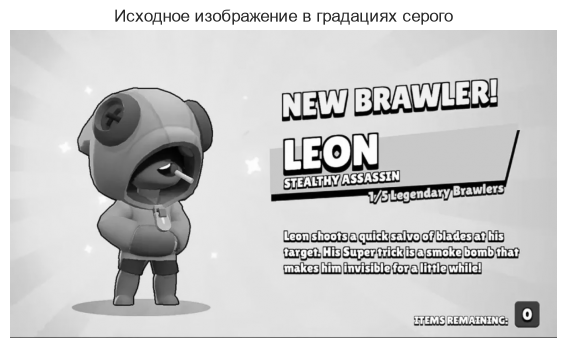

In [13]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
IMAGE_PATH = Path('image.png')
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f'Не найден файл {IMAGE_PATH.resolve()}')

image = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_GRAYSCALE)
if image is None:
    raise ValueError('OpenCV не смогла прочитать изображение')

height, width = image.shape
print(f'Размер изображения: {width} x {height} пикселей')
print(f'Диапазон яркости: {image.min()} ... {image.max()}')

plt.figure(figsize=(8, 4))
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title('Исходное изображение в градациях серого')
plt.axis('off')
plt.show()

## 1. Гистограмма исходного изображения

Пик гистограммы: интенсивность 225, 40194 пикс.


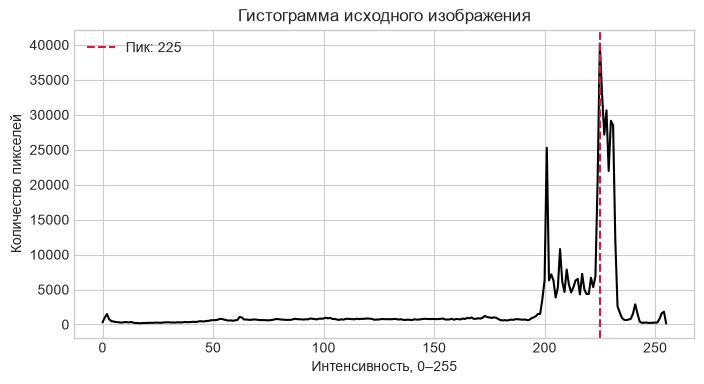

In [2]:
histogram = cv2.calcHist([image], [0], None, [256], [0, 256]).ravel()
peak_intensity = int(np.argmax(histogram))
peak_count = int(histogram[peak_intensity])
print(f'Пик гистограммы: интенсивность {peak_intensity}, {peak_count} пикс.')

plt.figure(figsize=(8, 4))
plt.plot(np.arange(256), histogram, color='black')
plt.axvline(peak_intensity, color='crimson', linestyle='--', label=f'Пик: {peak_intensity}')
plt.title('Гистограмма исходного изображения')
plt.xlabel('Интенсивность, 0–255')
plt.ylabel('Количество пикселей')
plt.legend()
plt.show()

## 2. Профили изображения после фильтра Лапласа

Максимум горизонтального профиля Лапласа: строка 562, 37.62
Максимум вертикального профиля Лапласа: столбец 501, 15.33


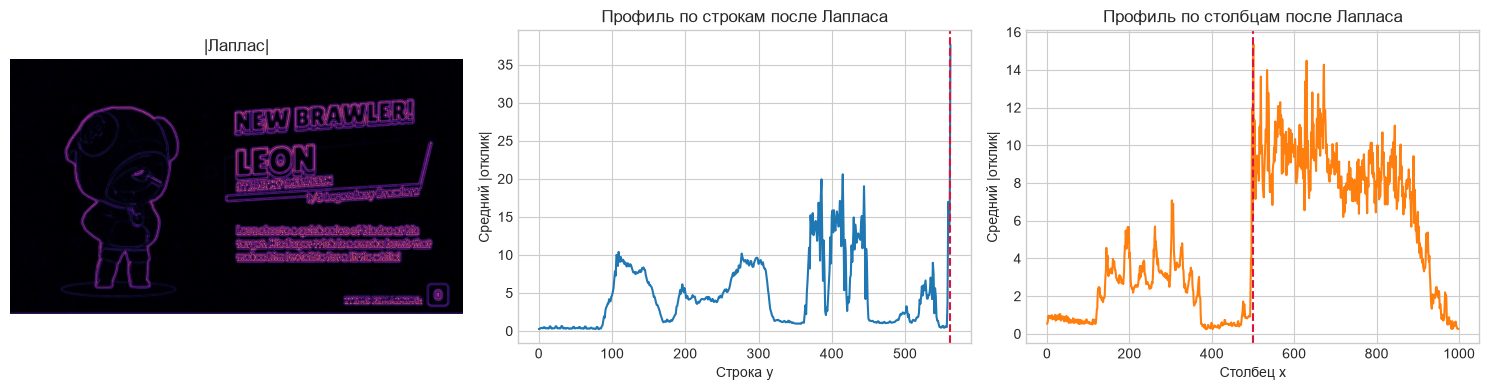

In [3]:
laplacian_signed = cv2.Laplacian(image, cv2.CV_64F)
laplacian = np.abs(laplacian_signed)
laplacian_horizontal_profile = laplacian.mean(axis=1)
laplacian_vertical_profile = laplacian.mean(axis=0)

max_lap_row = int(np.argmax(laplacian_horizontal_profile))
max_lap_col = int(np.argmax(laplacian_vertical_profile))
print(f'Максимум горизонтального профиля Лапласа: строка {max_lap_row}, {laplacian_horizontal_profile[max_lap_row]:.2f}')
print(f'Максимум вертикального профиля Лапласа: столбец {max_lap_col}, {laplacian_vertical_profile[max_lap_col]:.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(laplacian, cmap='magma')
axes[0].set_title('|Лаплас|')
axes[0].axis('off')
axes[1].plot(laplacian_horizontal_profile, color='tab:blue')
axes[1].axvline(max_lap_row, color='crimson', linestyle='--')
axes[1].set_title('Профиль по строкам после Лапласа')
axes[1].set_xlabel('Строка y')
axes[1].set_ylabel('Средний |отклик|')
axes[2].plot(laplacian_vertical_profile, color='tab:orange')
axes[2].axvline(max_lap_col, color='crimson', linestyle='--')
axes[2].set_title('Профиль по столбцам после Лапласа')
axes[2].set_xlabel('Столбец x')
axes[2].set_ylabel('Средний |отклик|')
plt.tight_layout()
plt.show()

## 3. Горизонтальная и вертикальная проекции исходного изображения

Максимум горизонтальной проекции: строка 85, 223713
Максимум вертикальной проекции: столбец 373, 129315


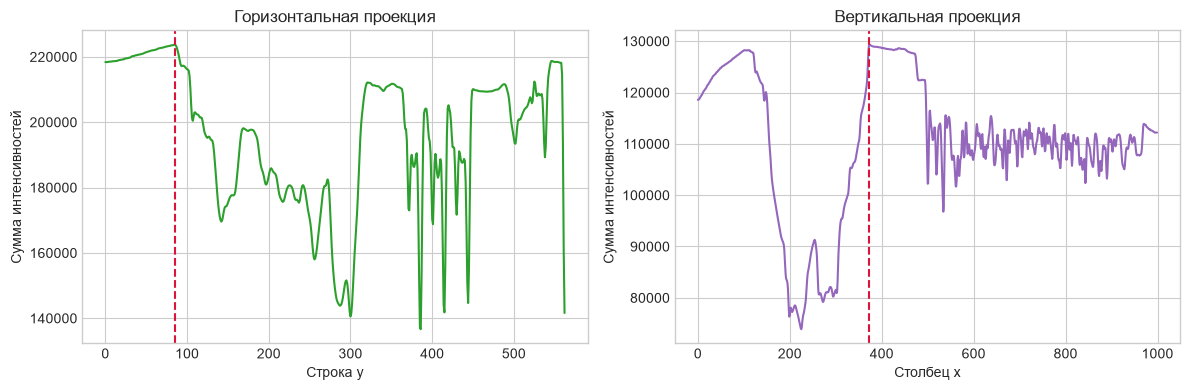

In [4]:
horizontal_projection = image.sum(axis=1)
vertical_projection = image.sum(axis=0)
max_projection_row = int(np.argmax(horizontal_projection))
max_projection_col = int(np.argmax(vertical_projection))
print(f'Максимум горизонтальной проекции: строка {max_projection_row}, {horizontal_projection[max_projection_row]:.0f}')
print(f'Максимум вертикальной проекции: столбец {max_projection_col}, {vertical_projection[max_projection_col]:.0f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(horizontal_projection, color='tab:green')
axes[0].axvline(max_projection_row, color='crimson', linestyle='--')
axes[0].set_title('Горизонтальная проекция')
axes[0].set_xlabel('Строка y')
axes[0].set_ylabel('Сумма интенсивностей')
axes[1].plot(vertical_projection, color='tab:purple')
axes[1].axvline(max_projection_col, color='crimson', linestyle='--')
axes[1].set_title('Вертикальная проекция')
axes[1].set_xlabel('Столбец x')
axes[1].set_ylabel('Сумма интенсивностей')
plt.tight_layout()
plt.show()

## 4. Бинаризация методом Отсу и повторный анализ

Порог Отсу: 152.00
Доля белых пикселей: 83.29%
Пик бинарной гистограммы: интенсивность 255, 468933 пикс.
Максимум бинарной горизонтальной проекции: строка 0
Максимум бинарной вертикальной проекции: столбец 7


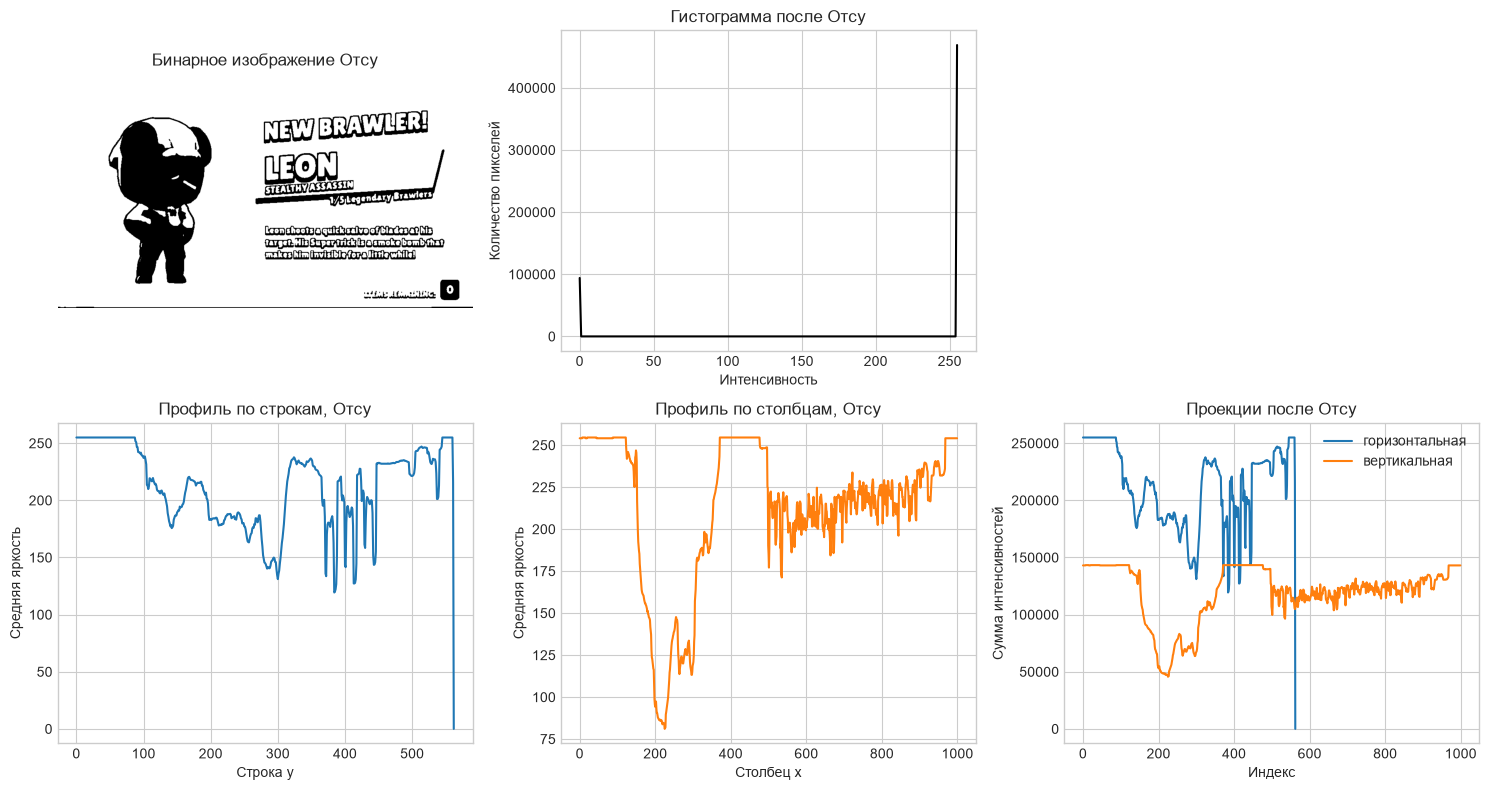

In [5]:
otsu_threshold, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
binary_histogram = cv2.calcHist([binary], [0], None, [256], [0, 256]).ravel()
binary_horizontal_profile = binary.mean(axis=1)
binary_vertical_profile = binary.mean(axis=0)
binary_horizontal_projection = binary.sum(axis=1)
binary_vertical_projection = binary.sum(axis=0)
binary_peak_intensity = int(np.argmax(binary_histogram))
binary_max_row = int(np.argmax(binary_horizontal_projection))
binary_max_col = int(np.argmax(binary_vertical_projection))
print(f'Порог Отсу: {otsu_threshold:.2f}')
print(f'Доля белых пикселей: {np.mean(binary == 255):.2%}')
print(f'Пик бинарной гистограммы: интенсивность {binary_peak_intensity}, {int(binary_histogram[binary_peak_intensity])} пикс.')
print(f'Максимум бинарной горизонтальной проекции: строка {binary_max_row}')
print(f'Максимум бинарной вертикальной проекции: столбец {binary_max_col}')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0, 0].imshow(binary, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Бинарное изображение Отсу')
axes[0, 0].axis('off')
axes[0, 1].plot(np.arange(256), binary_histogram, color='black')
axes[0, 1].set_title('Гистограмма после Отсу')
axes[0, 1].set_xlabel('Интенсивность')
axes[0, 1].set_ylabel('Количество пикселей')
axes[0, 2].axis('off')
axes[1, 0].plot(binary_horizontal_profile, color='tab:blue')
axes[1, 0].set_title('Профиль по строкам, Отсу')
axes[1, 0].set_xlabel('Строка y')
axes[1, 0].set_ylabel('Средняя яркость')
axes[1, 1].plot(binary_vertical_profile, color='tab:orange')
axes[1, 1].set_title('Профиль по столбцам, Отсу')
axes[1, 1].set_xlabel('Столбец x')
axes[1, 1].set_ylabel('Средняя яркость')
axes[1, 2].plot(binary_horizontal_projection, label='горизонтальная')
axes[1, 2].plot(binary_vertical_projection, label='вертикальная')
axes[1, 2].set_title('Проекции после Отсу')
axes[1, 2].set_xlabel('Индекс')
axes[1, 2].set_ylabel('Сумма интенсивностей')
axes[1, 2].legend()
plt.tight_layout()
plt.show()

## Вывод

Гистограмма показывает наиболее часто встречающиеся уровни яркости. Лаплас локализует строки и столбцы с наиболее сильными изменениями яркости. Проекции исходного изображения отражают суммарную светлую область, а после Отсу превращаются в удобные счётчики белых пикселей по строкам и столбцам. Поэтому бинарные проекции позволяют находить строки и столбцы, где сосредоточен объект.